# Welcome to Colab!

In [1]:
from google.colab import files

# Upload a file from your computer
uploaded = files.upload()

Saving Smart_City_Complaints_With_Missing_Duplicates.csv to Smart_City_Complaints_With_Missing_Duplicates.csv


Phase 1: Data Understanding & Cleaning
 Load dataset




In [2]:
import pandas as pd
df = pd.read_csv("Smart_City_Complaints_With_Missing_Duplicates.csv")

In [3]:
df.head()

,Complaint_ID,Complaint_Date,Resolved_Date,Category,Department,Zone,Priority,Status,Citizen_Satisfaction,Resolution_Delay_Days,Complaint_Description
0,CMP1000000,16-10-2025,24-10-2025,Garbage Collection,Sanitation,South,Low,Resolved,3.0,8.0,Garbage Collection issue reported by citizen
1,CMP1000001,23-11-2025,NaN,Drainage Problem,Drainage,North,Low,In Progress,2.0,NaN,Drainage Problem issue reported by citizen
2,CMP1000002,31-01-2024,01-02-2024,Garbage Collection,Sanitation,West,Medium,Resolved,5.0,1.0,Garbage Collection issue reported by citizen
3,CMP1000003,27-10-2025,15-11-2025,Drainage Problem,Drainage,North,Low,Resolved,4.0,19.0,Drainage Problem issue reported by citizen
4,CMP1000004,12-06-2024,19-06-2024,Drainage Problem,Drainage,South,Low,Resolved,4.0,7.0,Drainage Problem issue reported by citizen


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002000 entries, 0 to 1001999
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Complaint_ID           1002000 non-null  object 
 1   Complaint_Date         1002000 non-null  object 
 2   Resolved_Date          701906 non-null   object 
 3   Category               1002000 non-null  object 
 4   Department             1002000 non-null  object 
 5   Zone                   996990 non-null   object 
 6   Priority               996987 non-null   object 
 7   Status                 1002000 non-null  object 
 8   Citizen_Satisfaction   996997 non-null   float64
 9   Resolution_Delay_Days  701906 non-null   float64
 10  Complaint_Description  996990 non-null   object 
dtypes: float64(2), object(9)
memory usage: 84.1+ MB


Understand the Dataset
Check dimensions

In [5]:
df.shape

(1002000, 11)

View column names

In [6]:
df.columns

Index(['Complaint_ID', 'Complaint_Date', 'Resolved_Date', 'Category',
       'Department', 'Zone', 'Priority', 'Status', 'Citizen_Satisfaction',
       'Resolution_Delay_Days', 'Complaint_Description'],
      dtype='object')

Check Data Types

In [7]:
print(df.dtypes)

Complaint_ID              object
Complaint_Date            object
Resolved_Date             object
Category                  object
Department                object
Zone                      object
Priority                  object
Status                    object
Citizen_Satisfaction     float64
Resolution_Delay_Days    float64
Complaint_Description     object
dtype: object


Handle missing values

In [8]:
df.isnull().sum()

,0
Complaint_ID,0
Complaint_Date,0
Resolved_Date,300094
Category,0
Department,0
Zone,5010
Priority,5013
Status,0
Citizen_Satisfaction,5003
Resolution_Delay_Days,300094


In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

Complaint_ID              0.000000
Complaint_Date            0.000000
Resolved_Date            29.949501
Category                  0.000000
Department                0.000000
Zone                      0.500000
Priority                  0.500299
Status                    0.000000
Citizen_Satisfaction      0.499301
Resolution_Delay_Days    29.949501
Complaint_Description     0.500000
dtype: float64


Priority

Fill with mode:

In [10]:
df["Priority"] = df["Priority"].fillna(
    df["Priority"].mode()[0]
)

Zone

Fill with mode:

In [11]:
df["Zone"] = df["Zone"].fillna(
    df["Zone"].mode()[0]
)

Citizen Satisfaction

Fill with mean:

In [12]:
df["Citizen_Satisfaction"] = df["Citizen_Satisfaction"].fillna(
    df["Citizen_Satisfaction"].mean()
)

Complaint Description

Fill with text:

In [13]:
df["Complaint_Description"] = df[
    "Complaint_Description"
].fillna("No Description")

Check duplicates

In [14]:
print(df.duplicated().sum())

2000


Remove Duplicates

In [15]:
df = df.drop_duplicates()

In [16]:
print(df.duplicated().sum())

0


Convert date/time columns

In [17]:
df["Complaint_Date"] = pd.to_datetime(
    df["Complaint_Date"]
)

df["Resolved_Date"] = pd.to_datetime(
    df["Resolved_Date"]
)

/tmp/ipykernel_12234/3520807386.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Complaint_Date"] = pd.to_datetime(
/tmp/ipykernel_12234/3520807386.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Resolved_Date"] = pd.to_datetime(


In [18]:
print(df.dtypes)

Complaint_ID                     object
Complaint_Date           datetime64[ns]
Resolved_Date            datetime64[ns]
Category                         object
Department                       object
Zone                             object
Priority                         object
Status                           object
Citizen_Satisfaction            float64
Resolution_Delay_Days           float64
Complaint_Description            object
dtype: object


Clean complaint text descriptions|
Remove extra spaces

In [19]:
df["Category"] = df["Category"].str.strip()

df["Department"] = df["Department"].str.strip()

df["Zone"] = df["Zone"].str.strip()

Convert to title case:

In [20]:
df["Category"] = df["Category"].str.title()

df["Department"] = df["Department"].str.title()

Create derived variables |
Resolution Delay

In [21]:
df["Resolution_Delay"] = (
    df["Resolved_Date"]
    -
    df["Complaint_Date"]
).dt.days

Priority Score

In [22]:
priority_map = {
    "Low":1,
    "Medium":2,
    "High":3
}

df["Priority_Score"] = df[
    "Priority"
].map(priority_map)

Save Cleaned Dataset

In [23]:
df.to_csv(
    "Smart_City_Complaints_Cleaned.csv",
    index=False
)

Phase 2: KPI Design |
Total Complaints

In [24]:
total_complaints = len(df)

print("Total Complaints:", total_complaints)

Total Complaints: 1000000


Resolved Complaints

In [25]:
resolved_complaints = len(
    df[df["Status"]=="Resolved"]
)

print("Resolved Complaints:", resolved_complaints)

Resolved Complaints: 700491


Pending Complaints

In [26]:
pending_complaints = len(
    df[df["Status"]=="Pending"]
)


print("Pending Complaints:", pending_complaints)


Pending Complaints: 149720


Resolution Rate

In [27]:
resolution_rate = (
    resolved_complaints /
    total_complaints
) * 100

print("Resolution Rate:", round(resolution_rate,2), "%")

Resolution Rate: 70.05 %


Average Resolution Time

In [28]:
average_resolution = df[
    "Resolution_Delay_Days"
].mean()

print(
    "Average Resolution Time:",
    round(average_resolution,2),
    "days"
)

Average Resolution Time: 10.49 days


High Priority Complaints

In [29]:
high_priority = len(
    df[df["Priority"]=="High"]
)

print(
    "High Priority Complaints:",
    high_priority
)

High Priority Complaints: 149487


Citizen Satisfaction Score

In [30]:
average_satisfaction = df[
    "Citizen_Satisfaction"
].mean()

print(
    "Average Satisfaction:",
    round(average_satisfaction,2)
)

Average Satisfaction: 3.4


Complaint Hotspot Zones

In [31]:
zone_complaints = df[
    "Zone"
].value_counts()

print(zone_complaints)

Zone
South         104969
West           99855
North          99770
South-West     99565
North-West     99520
North-East     99404
South-East     99324
Central        99304
East           99205
Industrial     99084
Name: count, dtype: int64


Department Performance Score

In [32]:
department_complaints = df.groupby(
    "Department"
).size()

print(department_complaints)

Department
Drainage      143292
Electrical    142182
Police        142505
Roads         142350
Sanitation    142940
Traffic       143395
Water         143336
dtype: int64


Phase 3: Analytics Investigation  

Zone vs Complaint Count

In [34]:
zone_count = df.groupby("Zone").size().reset_index(name="Complaint_Count")

print(zone_count)

         Zone  Complaint_Count
0     Central            99304
1        East            99205
2  Industrial            99084
3       North            99770
4  North-East            99404
5  North-West            99520
6       South           104969
7  South-East            99324
8  South-West            99565
9        West            99855


Visualization

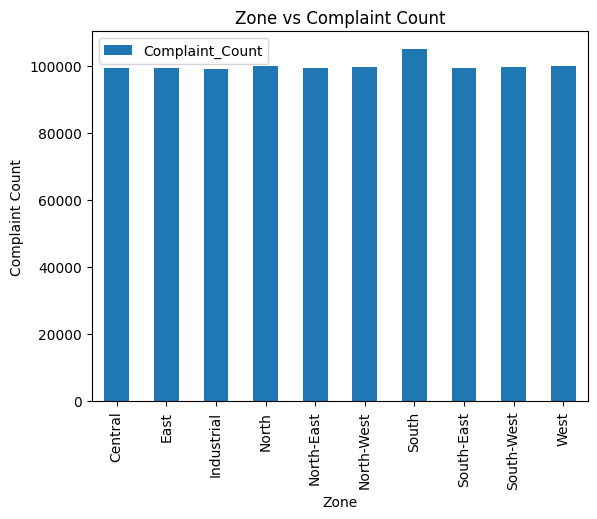

In [35]:
import matplotlib.pyplot as plt

zone_count.plot(
    x="Zone",
    y="Complaint_Count",
    kind="bar"
)

plt.xlabel("Zone")
plt.ylabel("Complaint Count")
plt.title("Zone vs Complaint Count")
plt.show()

Category vs Resolution Time

In [36]:
category_delay = df.groupby(
    "Category"
)["Resolution_Delay_Days"].mean().reset_index()

print(category_delay)

               Category  Resolution_Delay_Days
0      Drainage Problem              10.517812
1    Garbage Collection              10.452841
2         Public Safety              10.506068
3           Road Damage              10.501577
4  Street Light Failure              10.460944
5    Traffic Congestion              10.470376
6          Water Supply              10.486708


Visualization

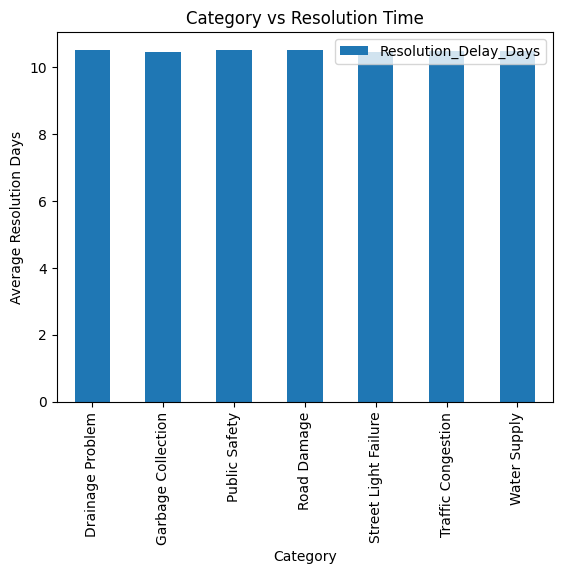

In [37]:
category_delay.plot(
    x="Category",
    y="Resolution_Delay_Days",
    kind="bar"
)

plt.xlabel("Category")
plt.ylabel("Average Resolution Days")
plt.title("Category vs Resolution Time")
plt.show()

Department vs Performance

Department
Sanitation    10.452841
Electrical    10.460944
Traffic       10.470376
Water         10.486708
Roads         10.501577
Police        10.506068
Drainage      10.517812
Name: Resolution_Delay_Days, dtype: float64


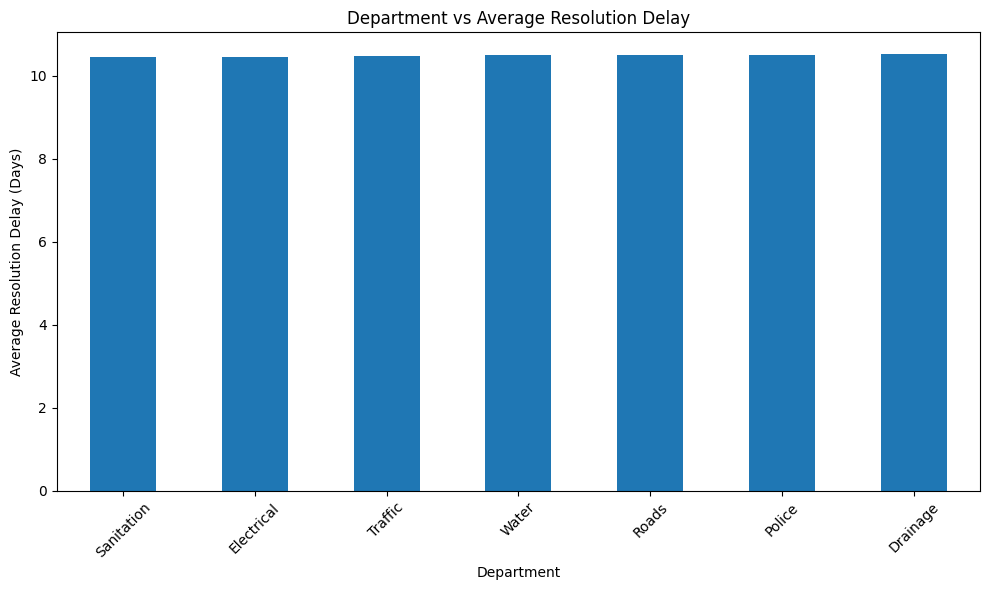

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by Department
dept_performance = (
    df.groupby('Department')['Resolution_Delay_Days']
      .mean()
      .sort_values()
)

print(dept_performance)

# Plot
plt.figure(figsize=(10, 6))
dept_performance.plot(kind='bar')
plt.title('Department vs Average Resolution Delay')
plt.xlabel('Department')
plt.ylabel('Average Resolution Delay (Days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Complaint Trends over Time

In [40]:
#Convert dates:

df["Complaint_Date"] = pd.to_datetime(
    df["Complaint_Date"]
)

#Monthly trend:

monthly = df.groupby(
    df["Complaint_Date"].dt.to_period("M")
).size()

print(monthly)

Complaint_Date
2024-01    42592
2024-02    39608
2024-03    42668
2024-04    40941
2024-05    42461
2024-06    41076
2024-07    42317
2024-08    42219
2024-09    40832
2024-10    42539
2024-11    41268
2024-12    42360
2025-01    42655
2025-02    38516
2025-03    42127
2025-04    40922
2025-05    42098
2025-06    41065
2025-07    42771
2025-08    42453
2025-09    40821
2025-10    42272
2025-11    41180
2025-12    42239
Freq: M, dtype: int64


Visualization

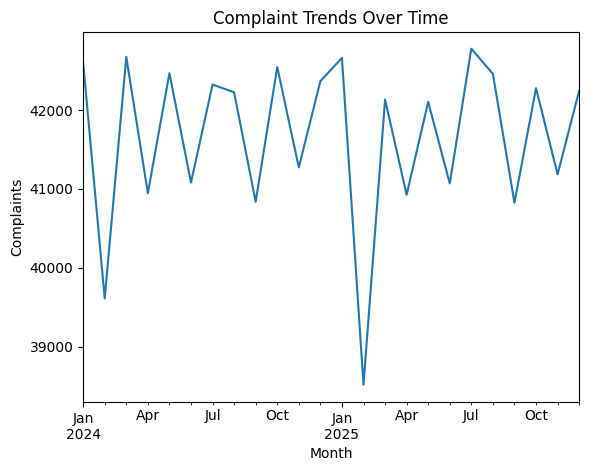

In [41]:
monthly.plot(kind="line")

plt.xlabel("Month")
plt.ylabel("Complaints")
plt.title("Complaint Trends Over Time")
plt.show()

Priority vs Resolution Delay

In [42]:
priority_delay = df.groupby(
    "Priority"
)["Resolution_Delay_Days"].mean()

print(priority_delay)

Priority
High      10.478340
Low       10.487780
Medium    10.484393
Name: Resolution_Delay_Days, dtype: float64


visualization

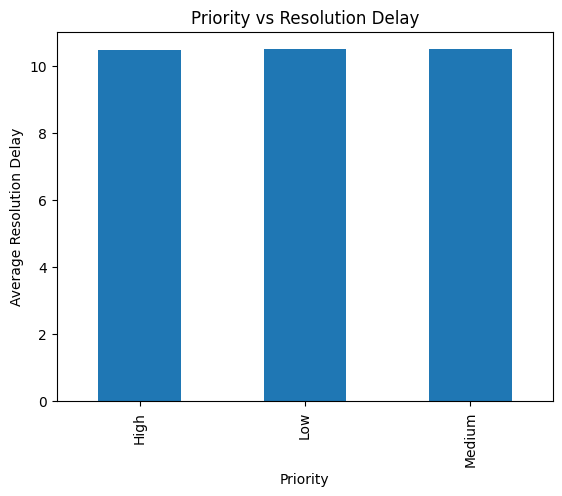

In [43]:
priority_delay.plot(kind="bar")

plt.xlabel("Priority")
plt.ylabel("Average Resolution Delay")
plt.title("Priority vs Resolution Delay")
plt.show()

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  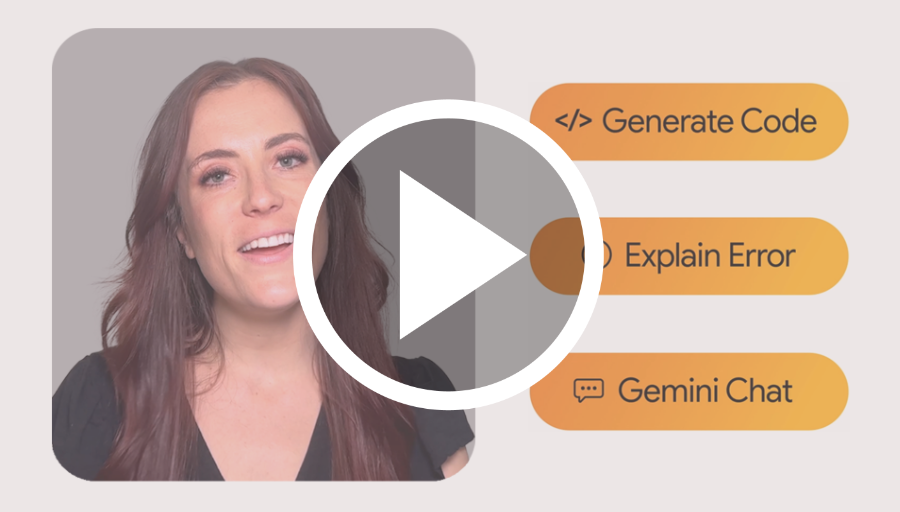
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [44]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [45]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

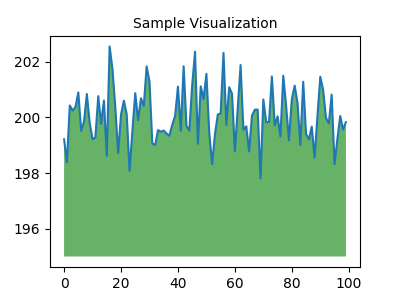

In [46]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
